# Base 04 — HumanAI Social-Cognitive

Pipeline completo da série diária de `EI` (intensity/emotional involvement), com documentação, EDA, limpeza, STL, feature engineering sem vazamento, tuning temporal, walk-forward, MAE, resíduos e interpretação.

**Execução:** este notebook segue o mesmo padrão da base 05. Os dados originais ficam em `../data/base_04/` e os artefatos derivados devem ser gravados em `../data/base_04/` e `../artifacts/base_04/`.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import pickle
import time
import warnings

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow
import seaborn as sns
import sklearn
import statsmodels
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

BASE_ID = "base_04"
RANDOM_STATE = 42
DATA_DIR = Path("../data") / BASE_ID
ARTIFACT_DIR = Path("../artifacts") / BASE_ID
RAW_FILE = DATA_DIR / "HumanAI Social-Cognitive new.csv"

DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_STATE)

assert RAW_FILE.exists(), f"Arquivo raw ausente: {RAW_FILE}"
print({
    'python': __import__('sys').version.split()[0],
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'sklearn': sklearn.__version__,
    'statsmodels': statsmodels.__version__,
    'matplotlib': matplotlib.__version__,
    'pyarrow': pyarrow.__version__,
})

{'python': '3.12.10', 'numpy': '2.2.2', 'pandas': '3.0.1', 'sklearn': '1.7.0', 'statsmodels': '0.14.6', 'matplotlib': '3.10.0', 'pyarrow': '20.0.0'}


## A–C. Documentação, EDA e limpeza

A base 04 reúne interações de conversas do conjunto HumanAI Social-Cognitive. Como a granularidade do raw é por turno/utterance, o processo de análise foca na construção de uma série diária para a métrica `EI` (emotional intensity), agregando médias por data. O objetivo é manter uma série temporal regular e com variáveis externas coerentes com a data de origem.

| Coluna | Tipo | Significado | Papel | Disponibilidade |
|---|---|---|---|---|
| `datetime` | datetime | timestamp da utterance | índice | `known_ahead` |
| `EI` | float | intensidade emocional | alvo | — |
| `SN` | float | social/relational signal | externa | `lag_only` |
| `TF` | float | valência / tone / arousal | externa | `lag_only` |
| `JP` | float | outro índice comportamental | externa | `lag_only` |
| `happiness` | float | humor positivo | externa | `lag_only` |
| `sadness` | float | humor negativo | externa | `lag_only` |
| `surprise` | float | surpresa | externa | `lag_only` |
| `Relationship` | float | nível relacional | externa | `lag_only` |

A série alvo é a média diária de `EI`; as variáveis externas são também médias diárias por data. Como o horizonte é de um passo (`h=1`), apenas valores observados até a data de origem podem ser usados.

In [2]:
raw = pd.read_csv(RAW_FILE)
print(raw.head(2).to_string(index=False))
print(f"Linhas raw: {len(raw)}; colunas: {len(raw.columns)}")

numeric_cols = [
    'EI', 'SN', 'TF', 'JP', 'no_emotion', 'anger', 'disgust', 'fear', 'happiness', 'sadness',
    'surprise', 'E0', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'P0', 'P1', 'P2', 'P3',
    'M0', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'M10', 'Relationship'
]

def parse_numeric(value):
    if pd.isna(value):
        return np.nan
    s = str(value).strip()
    if s in {'', 'nan', 'NaN', 'None'}:
        return np.nan
    if ',' in s and '.' in s:
        s = s.replace('.', '').replace(',', '.')
    elif ',' in s:
        s = s.replace(',', '.')
    if s.count('.') > 1:
        s = s.replace('.', '')
    return float(s)

for col in numeric_cols:
    if col in raw.columns:
        raw[col] = raw[col].apply(parse_numeric)

raw['datetime'] = pd.to_datetime(raw['datetime'], errors='coerce')
raw = raw.dropna(subset=['datetime']).sort_values('datetime').reset_index(drop=True)
raw['Date'] = raw['datetime'].dt.normalize()

daily = (
    raw.groupby('Date', as_index=True)
    .agg(
        target=('EI', 'mean'),
        sn=('SN', 'mean'),
        tf=('TF', 'mean'),
        jp=('JP', 'mean'),
        happiness=('happiness', 'mean'),
        sadness=('sadness', 'mean'),
        surprise=('surprise', 'mean'),
        relationship=('Relationship', 'mean'),
        utterances=('text', 'count'),
    )
    .reset_index()
)
daily = daily.sort_values('Date').reset_index(drop=True)
display(daily.head())
print(f"Série diária: {daily.shape[0]} linhas")

integrity = {
    'rows': len(daily),
    'start': daily['Date'].min(),
    'end': daily['Date'].max(),
    'missing_total': int(daily.isna().sum().sum()),
    'duplicate_dates': int(daily['Date'].duplicated().sum()),
    'nonpositive_target': int((daily['target'] <= 0).sum()),
    'negative_utterances': int((daily['utterances'] < 0).sum()),
}
display(pd.Series(integrity, name='value').to_frame())
assert integrity['rows'] > 0
assert integrity['missing_total'] == 0
assert integrity['duplicate_dates'] == 0

cleaned = daily.copy()
cleaned.to_csv(DATA_DIR / f"cleaned_{BASE_ID}.csv", index=False)
print(f"Limpo salvo em {DATA_DIR / f'cleaned_{BASE_ID}.csv'}")

dataset conversation_key  conversation_id  session  turn  utterance_id      role  speaker            datetime                                                                                               text   EI   SN   TF   JP  no_emotion  anger  disgust  fear  happiness  sadness  surprise   E0  E1  E2  E3   E4  E5   E6   P0   P1   P2   P3                     M0  M1  M2  M3   M4  M5   M6   M7                     M8   M9  M10          Relationship
 LoCoMo         LoCoMo_0                0        1     1             1      user CAROLINE 2023-05-08 13:56:00                                                       Hey Mel! Good to see you! How have you been? 0.21 0.11 0.91 0.66        0.29    0.0      0.0   0.0       0.55      0.0      0.06 0.29 0.0 0.0 0.0 0.55 0.0 0.06 0.21 0.11 0.91 0.66                   0.29 0.0 0.0 0.0 0.55 0.0 0.06 0.21                   0.11 0.91 0.66                   1.0
 LoCoMo         LoCoMo_0                0        1     2             2 assistant  MELANIE 2023

,Date,target,sn,tf,jp,happiness,sadness,surprise,relationship,utterances
0,2022-01-21,0.218182,0.151818,0.840000,0.700909,0.390000,0.000000,0.034091,8.226778e+15,22
1,2022-01-23,0.194828,0.135862,0.841724,0.699655,0.422414,0.000000,0.064828,9.218665e+15,29
2,2022-02-07,0.188800,0.144000,0.795600,0.709600,0.482800,0.000000,0.045200,8.899012e+15,25
3,2022-02-25,0.173684,0.126316,0.857895,0.703684,0.421053,0.000000,0.056842,7.956821e+15,19
4,2022-03-17,0.174595,0.146757,0.776486,0.692973,0.339459,0.001892,0.038919,8.839479e+15,37


Série diária: 218 linhas


,value
rows,218
start,2022-01-21 00:00:00
end,2024-01-12 00:00:00
missing_total,0
duplicate_dates,0
nonpositive_target,0
negative_utterances,0


Limpo salvo em ..\data\base_04\cleaned_base_04.csv


### Decisões de limpeza

| Etapa | Decisão | Justificativa |
|---|---|---|
| Parse de `datetime` | normalização para `Date` em UTC/sem timezone | a série é observacional e deve ser tratada como diária |
| Agregação por dia | média diária de `EI` e variáveis externas | ajusta a granularidade da conversa para uma série temporal regular |
| Missing | remoção de linhas com datas inválidas | evita ruído em séries diárias |
| Outliers | preservar | choques emocionais reais são parte do processo e não necessariamente ruído |
| Alvo | média de `EI` por dia | mantém escala interpretable e compatível com MAE |

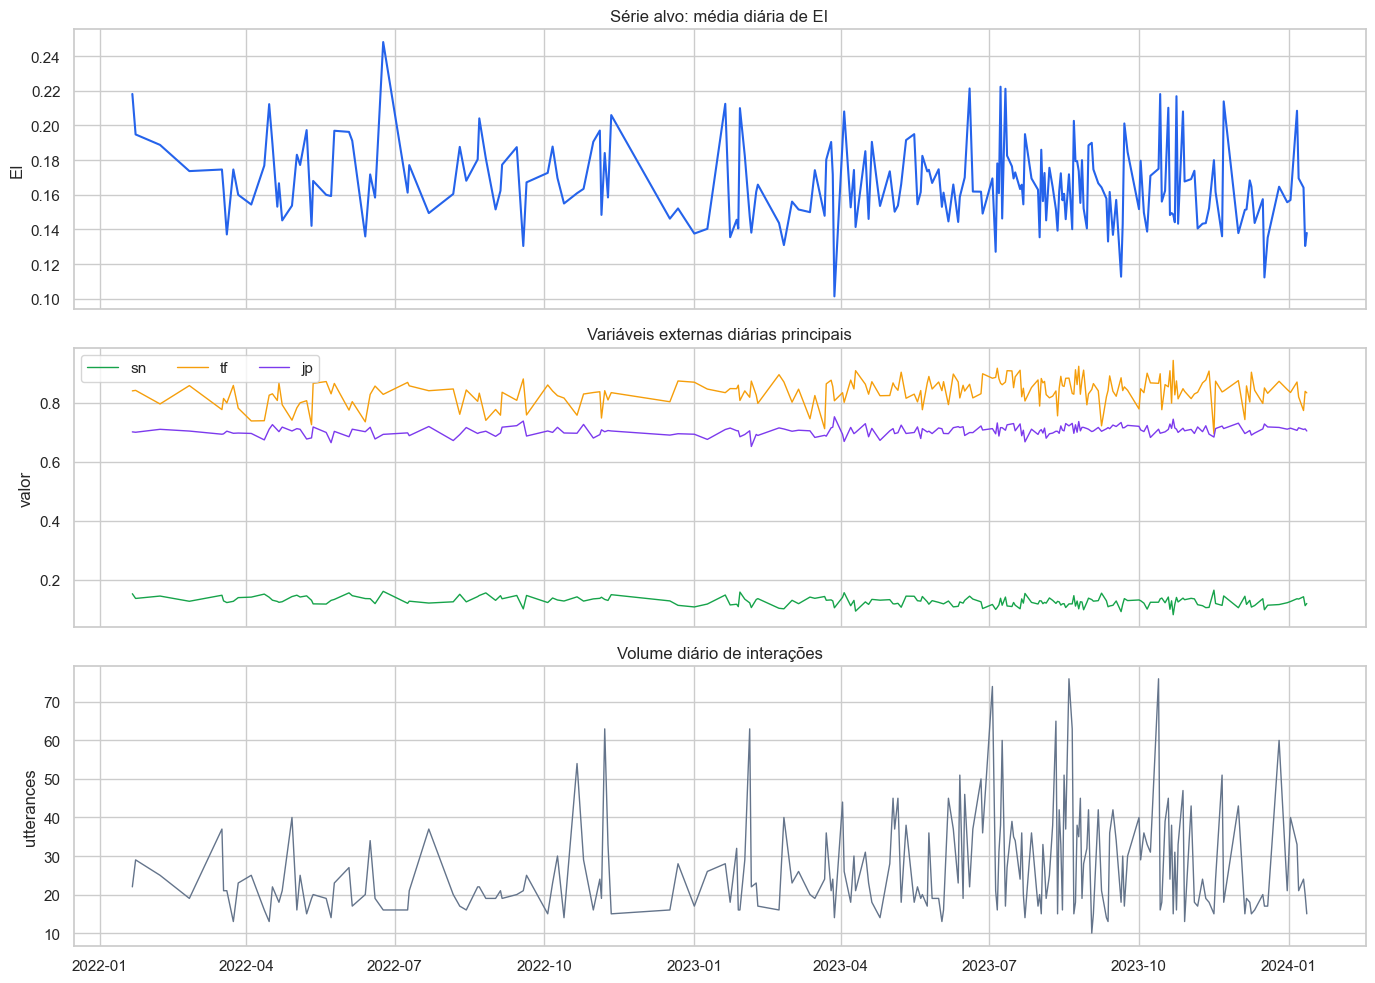

        Date    target        sn        tf        jp  happiness   sadness  \
0 2022-01-21  0.218182  0.151818  0.840000  0.700909   0.390000  0.000000   
1 2022-01-23  0.194828  0.135862  0.841724  0.699655   0.422414  0.000000   
2 2022-02-07  0.188800  0.144000  0.795600  0.709600   0.482800  0.000000   
3 2022-02-25  0.173684  0.126316  0.857895  0.703684   0.421053  0.000000   
4 2022-03-17  0.174595  0.146757  0.776486  0.692973   0.339459  0.001892   

   surprise  relationship  
0  0.034091  8.226778e+15  
1  0.064828  9.218665e+15  
2  0.045200  8.899012e+15  
3  0.056842  7.956821e+15  
4  0.038919  8.839479e+15  


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(cleaned['Date'], cleaned['target'], color='#2563eb', linewidth=1.5)
axes[0].set_title('Série alvo: média diária de EI')
axes[0].set_ylabel('EI')

for col, color in [('sn', '#16a34a'), ('tf', '#f59e0b'), ('jp', '#7c3aed')]:
    axes[1].plot(cleaned['Date'], cleaned[col], label=col, color=color, linewidth=1.0)
axes[1].legend(ncol=3)
axes[1].set_title('Variáveis externas diárias principais')
axes[1].set_ylabel('valor')

axes[2].plot(cleaned['Date'], cleaned['utterances'], color='#64748b', linewidth=1.0)
axes[2].set_title('Volume diário de interações')
axes[2].set_ylabel('utterances')
plt.tight_layout()
plt.show()

print(cleaned[['Date', 'target', 'sn', 'tf', 'jp', 'happiness', 'sadness', 'surprise', 'relationship']].head())

## D. STL, ACF/PACF e força da sazonalidade

A base 04 tem natureza temporal diária, com potencial sazonalidade semanal. Neste notebook usamos períodos candidatos em `{5, 7, 14, 30}` para verificar a força da sazonalidade e orientar a validação. O teste final guarda a regra da base 05: o conjunto de teste nunca entra no tuning.

{'development_end': Timestamp('2023-10-02 00:00:00'), 'test_start': Timestamp('2023-10-04 00:00:00'), 'test_observations': 43}


,series,adf_stat,p_value,lags,n,crit_5pct,stationary_5pct
0,EI (nível),-9.544635,2.669578e-16,2,215,-2.875079,True
1,EI (1ª diferença),-7.619683,2.144909e-11,11,205,-2.875744,True
2,EI (retorno),-8.818173,1.909024e-14,6,210,-2.875404,True


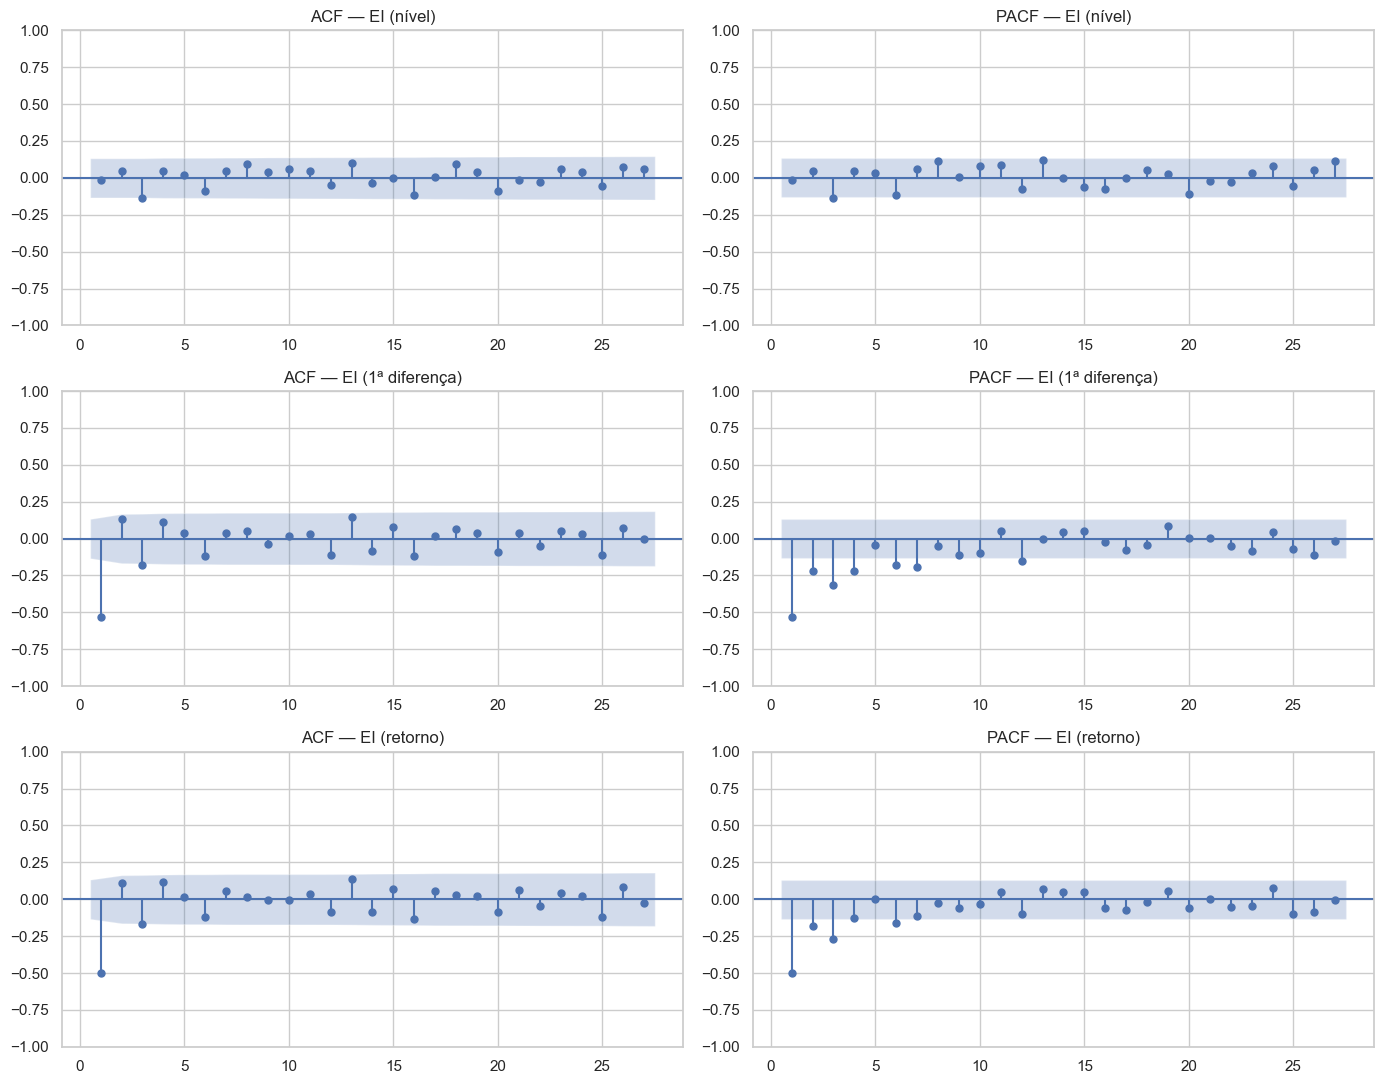

,m,seasonality_strength
2,14,0.225158
0,5,0.222351
3,30,0.155185
1,7,0.072097


Período sazonal dominante: m=14


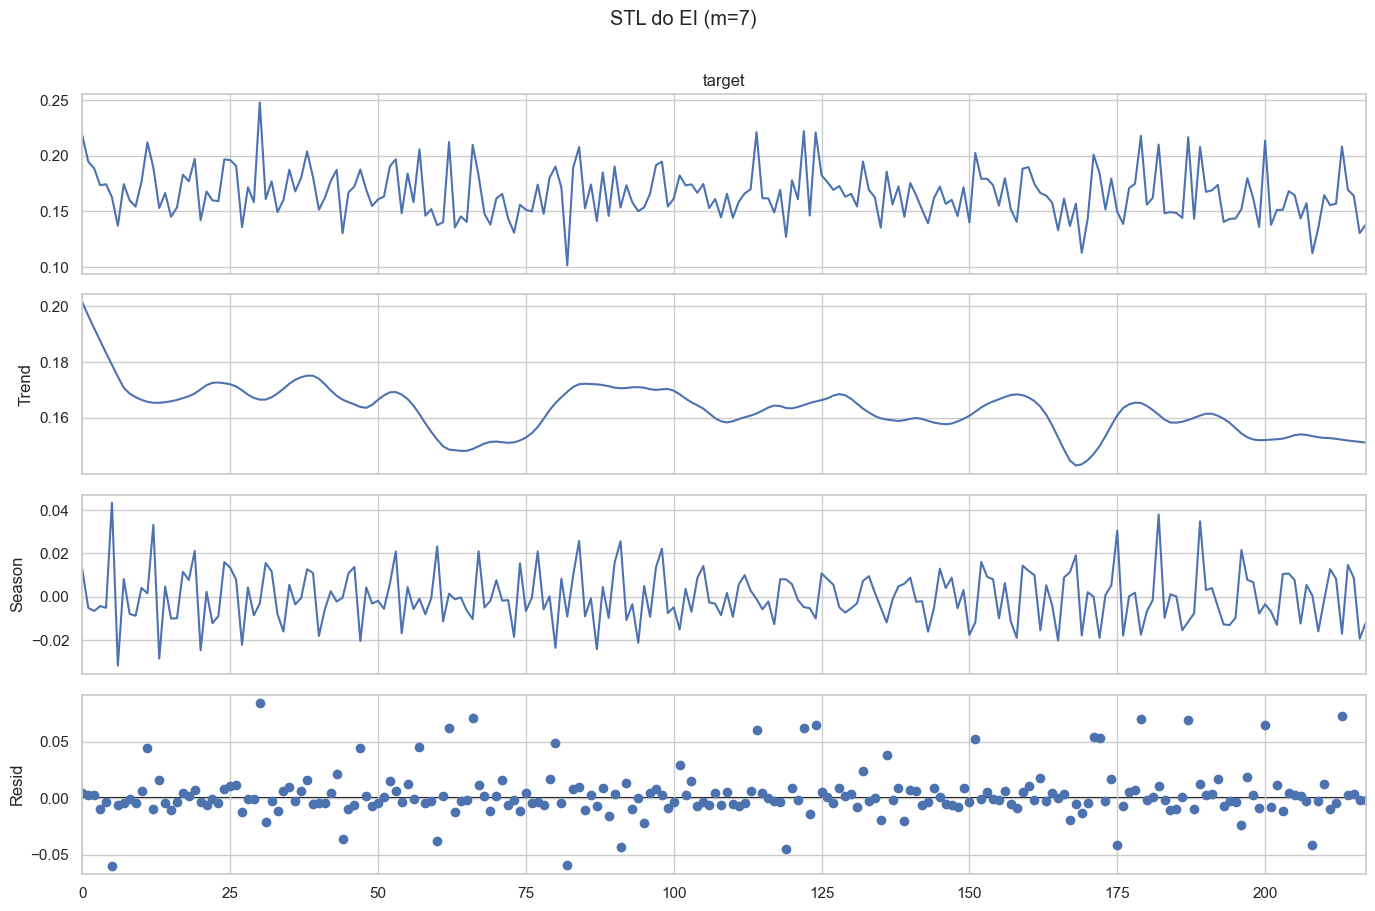

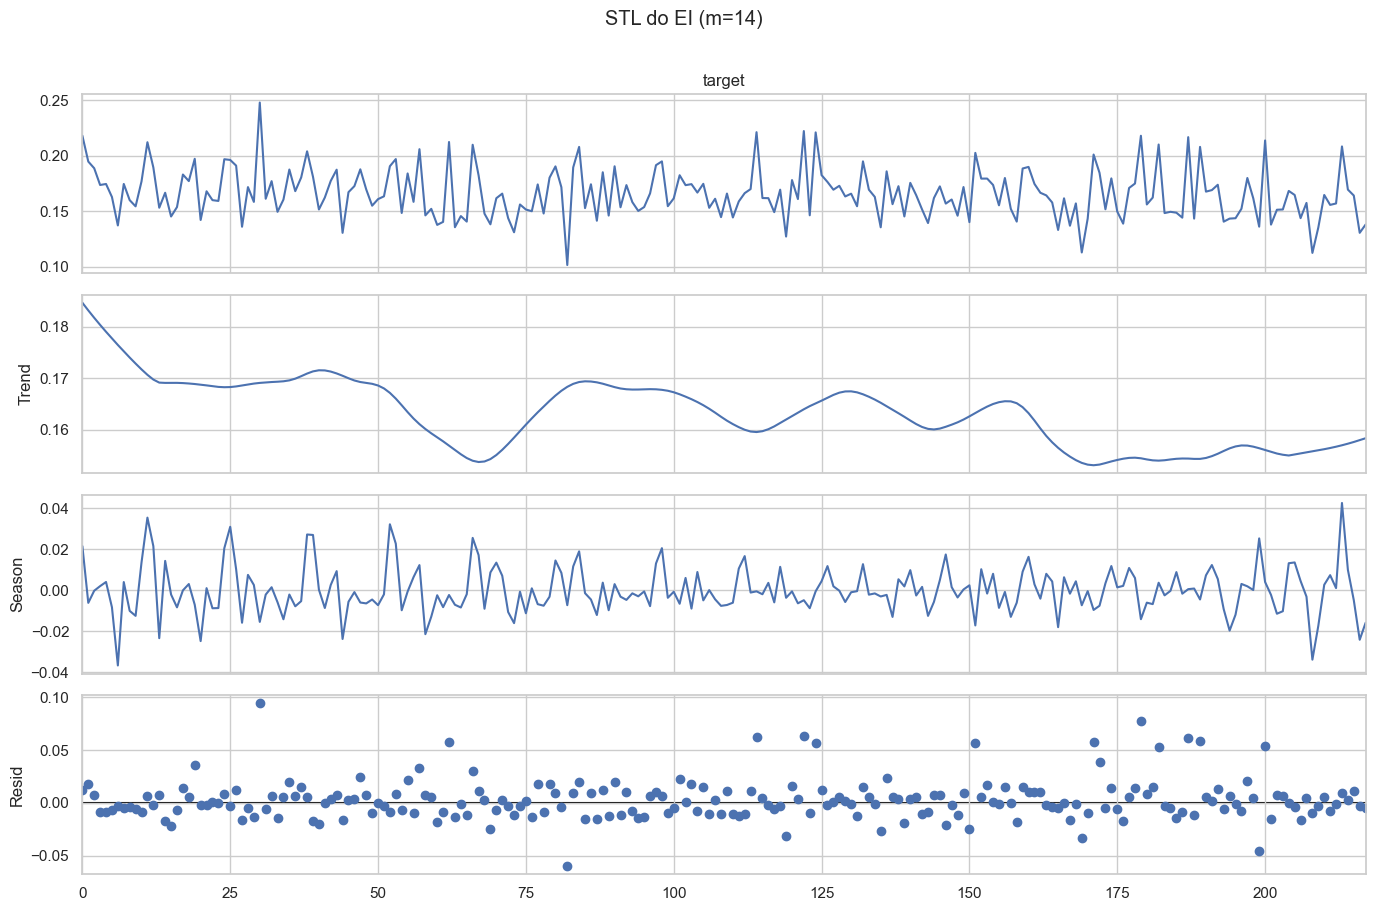

In [4]:
HORIZON = 1
TRAIN_MIN_OBS = 90
TEST_OBS = min(60, max(30, len(cleaned) // 5))
PERIOD_CANDIDATES = [5, 7, 14, 30]

test_start_idx = len(cleaned) - TEST_OBS
development_end = cleaned.loc[test_start_idx - 1, 'Date']
test_start = cleaned.loc[test_start_idx, 'Date']
print({'development_end': development_end, 'test_start': test_start, 'test_observations': TEST_OBS})

series = cleaned['target'].dropna()

def adf_summary(s, name):
    s = pd.Series(s).dropna()
    stat, pvalue, usedlag, nobs, crit, _ = adfuller(s, autolag='AIC')
    return {
        'series': name,
        'adf_stat': float(stat),
        'p_value': float(pvalue),
        'lags': int(usedlag),
        'n': int(nobs),
        'crit_5pct': float(crit['5%']),
        'stationary_5pct': pvalue < 0.05,
    }

level = series
diff1 = series.diff().dropna()
returns = series.pct_change().dropna()
display(pd.DataFrame([
    adf_summary(level, 'EI (nível)'),
    adf_summary(diff1, 'EI (1ª diferença)'),
    adf_summary(returns, 'EI (retorno)'),
]))

acf_lags = min(40, max(10, len(level) // 8))
fig, axes = plt.subplots(3, 2, figsize=(14, 11))
for row, (ser, title) in enumerate([(level, 'EI (nível)'), (diff1, 'EI (1ª diferença)'), (returns, 'EI (retorno)')]):
    plot_acf(ser, lags=acf_lags, ax=axes[row, 0], zero=False)
    plot_pacf(ser, lags=acf_lags, ax=axes[row, 1], zero=False, method='ywm')
    axes[row, 0].set_title(f'ACF — {title}')
    axes[row, 1].set_title(f'PACF — {title}')
plt.tight_layout()
plt.show()

seasonality_rows = []
for period in PERIOD_CANDIDATES:
    fitted = STL(series, period=period, robust=True).fit()
    strength = max(0.0, 1.0 - np.var(fitted.resid, ddof=1) / np.var(fitted.seasonal + fitted.resid, ddof=1))
    seasonality_rows.append({'m': period, 'seasonality_strength': float(strength)})
seasonality_table = pd.DataFrame(seasonality_rows).sort_values('seasonality_strength', ascending=False)
display(seasonality_table)
best_m = int(seasonality_table.iloc[0]['m'])
print(f'Período sazonal dominante: m={best_m}')

for period in [7, 14]:
    fig = STL(cleaned['target'], period=period, robust=True).fit().plot()
    fig.set_size_inches(14, 9)
    plt.suptitle(f'STL do EI (m={period})', y=1.01)
    plt.tight_layout()
    plt.show()

## E. Feature engineering e contrato anti-vazamento

Para a base 04, o alvo diário `target = EI` é previsto com base em valores passados do próprio alvo e de variáveis externas. Todas as features são construídas com `shift(1)` e janelas móveis em origem, para garantir que a informação do pregão futuro não seja usada.

Features finais comuns ao Random Forest e Elastic Net:
- `target_lag_1`, `target_lag_7`
- `sn_lag_1`, `tf_lag_1`, `jp_lag_1`, `happiness_lag_1`, `sadness_lag_1`, `surprise_lag_1`, `relationship_lag_1`
- médias e desvios das janelas de 7 e 30 dias
- calendário da data prevista: mês, fim de mês, seno/cosseno do dia do ano e do dia da semana

In [5]:
def build_samples(frame):
    x = frame.copy().set_index('Date')
    target = x['target']
    ret = target.pct_change()
    samples = pd.DataFrame(index=x.index)
    samples['origin_date'] = samples.index.to_series().shift(1)
    samples['forecast_date'] = samples.index
    samples['horizon_step'] = 1
    samples['target_lag_1'] = target.shift(1)
    samples['target_lag_7'] = target.shift(7)
    for col in ['sn', 'tf', 'jp', 'happiness', 'sadness', 'surprise', 'relationship']:
        samples[f'{col}_lag_1'] = x[col].shift(1)
    for window in [7, 30]:
        samples[f'target_mean_{window}'] = target.shift(1).rolling(window).mean()
        samples[f'target_std_{window}'] = target.shift(1).rolling(window).std()
        samples[f'return_mean_{window}'] = ret.shift(1).rolling(window).mean()
        samples[f'return_std_{window}'] = ret.shift(1).rolling(window).std()
    forecast_dates = pd.Series(samples.index, index=samples.index)
    dow = forecast_dates.dt.dayofweek
    doy = forecast_dates.dt.dayofyear
    samples['month'] = forecast_dates.dt.month
    samples['is_month_end'] = forecast_dates.dt.is_month_end.astype(int)
    samples['dow_sin'] = np.sin(2 * np.pi * dow / 7)
    samples['dow_cos'] = np.cos(2 * np.pi * dow / 7)
    samples['doy_sin'] = np.sin(2 * np.pi * doy / 365.25)
    samples['doy_cos'] = np.cos(2 * np.pi * doy / 365.25)
    samples['observed_source_max_date'] = samples['origin_date']
    samples['target'] = target
    return samples.dropna().reset_index(drop=True)

samples = build_samples(cleaned)
key_cols = ['origin_date', 'forecast_date', 'horizon_step']
audit_cols = ['observed_source_max_date']
feature_cols = [c for c in samples.columns if c not in key_cols + audit_cols + ['target']]
assert (samples['observed_source_max_date'] <= samples['origin_date']).all()
assert (samples['origin_date'] < samples['forecast_date']).all()
assert not samples[feature_cols + ['target']].isna().any().any()

samples.to_parquet(DATA_DIR / f'features_{BASE_ID}.parquet', index=False)
print(f'{len(feature_cols)} features; {len(samples)} amostras; anti-leakage validado.')
display(samples.head(3))

23 features; 187 amostras; anti-leakage validado.


,origin_date,forecast_date,horizon_step,target_lag_1,target_lag_7,sn_lag_1,tf_lag_1,jp_lag_1,happiness_lag_1,sadness_lag_1,...,return_mean_30,return_std_30,month,is_month_end,dow_sin,dow_cos,doy_sin,doy_cos,observed_source_max_date,target
0,2022-06-24,2022-07-09,1,0.248125,0.196957,0.160000,0.828125,0.692500,0.427500,0.000000,...,0.019137,0.181719,7,0,-0.974928,-0.222521,-0.126528,-0.991963,2022-06-24,0.161250
1,2022-07-09,2022-07-10,1,0.161250,0.196296,0.119375,0.868750,0.697500,0.373125,0.000000,...,0.011034,0.192631,7,0,-0.781831,0.623490,-0.143572,-0.989640,2022-07-09,0.177143
2,2022-07-10,2022-07-22,1,0.177143,0.191176,0.126667,0.857143,0.688095,0.522381,0.002857,...,0.015351,0.193109,7,0,-0.433884,-0.900969,-0.343367,-0.939201,2022-07-10,0.149459


Checklist anti-leakage:

- [x] todas as features têm origem em dados conhecidos antes da data prevista
- [x] não há uso de valores contemporâneos ao passo previsto
- [x] `Date` é tratada como data de origem e não como informação futura
- [x] o scaler do Elastic Net fica dentro do pipeline
- [x] o teste final é separado antes do tuning

## F. GridSearch temporal e motor walk-forward

A base 04 segue o mesmo protocolo da base 05: desenvolvimento até o último `TEST_OBS` dias e teste final em horizonte `h=1`. O tuning usa origens expansivas e o conjunto de teste permanece blindado até o fim.

In [6]:
development = samples[samples['forecast_date'] < test_start].reset_index(drop=True)
test_samples = samples[samples['forecast_date'] >= test_start].reset_index(drop=True)
print({'development_rows': len(development), 'test_rows': len(test_samples)})
assert len(test_samples) == TEST_OBS

sarimax_features = ['sn_lag_1', 'tf_lag_1', 'happiness_lag_1', 'surprise_lag_1', 'relationship_lag_1']

def jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [jsonable(v) for v in obj]
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if obj is None or isinstance(obj, (str, bool, int, float)):
        return obj
    return str(obj)

from itertools import product

sarimax_candidates = []
for order in product([0, 1, 2], [0, 1], [0, 1, 2]):
    sarimax_candidates.append({'order': order, 'seasonal_order': (0, 0, 0, 7)})
    for seasonal_order in product([0, 1], [0, 1], [0, 1], [7, 14, 30]):
        if seasonal_order[:3] == (0, 0, 0):
            continue
        sarimax_candidates.append({'order': order, 'seasonal_order': seasonal_order})

hw_candidates = []
for trend in [None, 'add', 'mul']:
    damped_options = [False] if trend is None else [False, True]
    for damped_trend in damped_options:
        hw_candidates.append({'trend': trend, 'damped_trend': damped_trend, 'seasonal': None, 'seasonal_periods': None})
        for seasonal, period in product(['add', 'mul'], [7, 14]):
            hw_candidates.append({'trend': trend, 'damped_trend': damped_trend, 'seasonal': seasonal, 'seasonal_periods': period})

cv = TimeSeriesSplit(n_splits=5)
rf_base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)
rf_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [6, 12, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.5, 1.0],
}
en_base = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(max_iter=20000, random_state=RANDOM_STATE)),
])
en_grid = {
    'model__alpha': [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0],
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
}

rf_gs = GridSearchCV(rf_base, rf_grid, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1, refit=True, verbose=1)
rf_gs.fit(development[feature_cols], development['target'])

en_gs = GridSearchCV(en_base, en_grid, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1, refit=True, verbose=1)
en_gs.fit(development[feature_cols], development['target'])

rf_params = rf_gs.best_params_
en_params = en_gs.best_params_
print('RF best params:', rf_params)
print('Elastic Net best params:', en_params)

selected_params = {
    'random_forest': rf_params,
    'elastic_net': en_params,
}

with open(DATA_DIR / f'hyperparams_random_forest_{BASE_ID}.json', 'w') as f:
    json.dump({'base_id': BASE_ID, 'model': 'random_forest', 'hyperparams': rf_params}, f, indent=2)
with open(DATA_DIR / f'hyperparams_elastic_net_{BASE_ID}.json', 'w') as f:
    json.dump({'base_id': BASE_ID, 'model': 'elastic_net', 'hyperparams': en_params}, f, indent=2)
print('Hyperparams salvos para RF e Elastic Net.')

{'development_rows': 144, 'test_rows': 43}
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
RF best params: {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 400}
Elastic Net best params: {'model__alpha': 0.01, 'model__l1_ratio': 0.9}
Hyperparams salvos para RF e Elastic Net.


In [7]:
model_names = ['sarimax', 'holt_winters', 'random_forest', 'elastic_net']
predictions = {}

for model_name in model_names:
    rows = []
    for _, current_row in test_samples.iterrows():
        current = current_row.to_frame().T
        origin = current_row['origin_date']
        train = samples[samples['forecast_date'] <= origin].reset_index(drop=True)
        if model_name == 'sarimax':
            model = SARIMAX(
                train['target'],
                exog=train[sarimax_features],
                order=(1, 0, 1),
                seasonal_order=(0, 0, 0, 7),
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False, maxiter=100)
            y_pred = float(model.forecast(1, exog=current[sarimax_features].astype(float)).iloc[0])
        elif model_name == 'holt_winters':
            model = ExponentialSmoothing(
                train['target'].to_numpy(),
                trend='add',
                damped_trend=False,
                seasonal='add',
                seasonal_periods=7,
                initialization_method='estimated',
            ).fit(optimized=True)
            y_pred = float(model.forecast(1)[0])
        elif model_name == 'random_forest':
            model = clone(rf_base).set_params(**rf_params)
            model.fit(train[feature_cols], train['target'])
            y_pred = float(model.predict(current[feature_cols].astype(float))[0])
        else:
            model = clone(en_base).set_params(**en_params)
            model.fit(train[feature_cols], train['target'])
            y_pred = float(model.predict(current[feature_cols].astype(float))[0])
        rows.append({
            'origin_date': origin,
            'forecast_date': current_row['forecast_date'],
            'horizon_step': 1,
            'y_true': current_row['target'],
            'y_pred': y_pred,
        })
    pred_df = pd.DataFrame(rows)
    predictions[model_name] = pred_df
    pred_df.to_csv(DATA_DIR / f'predictions_{model_name}_{BASE_ID}.csv', index=False)
    print(model_name, len(pred_df), 'previsões salvas.')

mae_rows = []
for model_name, pred_df in predictions.items():
    score = float(np.mean(np.abs(pred_df['y_true'] - pred_df['y_pred'])))
    mae_rows.append({
        'base_id': BASE_ID,
        'model': model_name,
        'mae': score,
        'n_predictions': len(pred_df),
    })
mae_table = pd.DataFrame(mae_rows).sort_values('mae').reset_index(drop=True)
mae_table['rank'] = np.arange(1, len(mae_table) + 1)
mae_table = mae_table[['base_id', 'model', 'mae', 'rank', 'n_predictions']]
mae_table.to_csv(DATA_DIR / f'mae_{BASE_ID}.csv', index=False)
display(mae_table)

sarimax 43 previsões salvas.
holt_winters 43 previsões salvas.
random_forest 43 previsões salvas.
elastic_net 43 previsões salvas.


,base_id,model,mae,rank,n_predictions
0,base_04,random_forest,0.019045,1,43
1,base_04,elastic_net,0.019784,2,43
2,base_04,holt_winters,0.020285,3,43
3,base_04,sarimax,0.049118,4,43


## G. Resíduos OOS, ACF, PACF e Ljung–Box

A análise de resíduos verifica se os modelos capturam a dinâmica temporal da série ou se ainda resta autocorrelação esperada. Em cada modelo, a sequência de resíduos é analisada estatisticamente e persistida em CSV para o relatório.

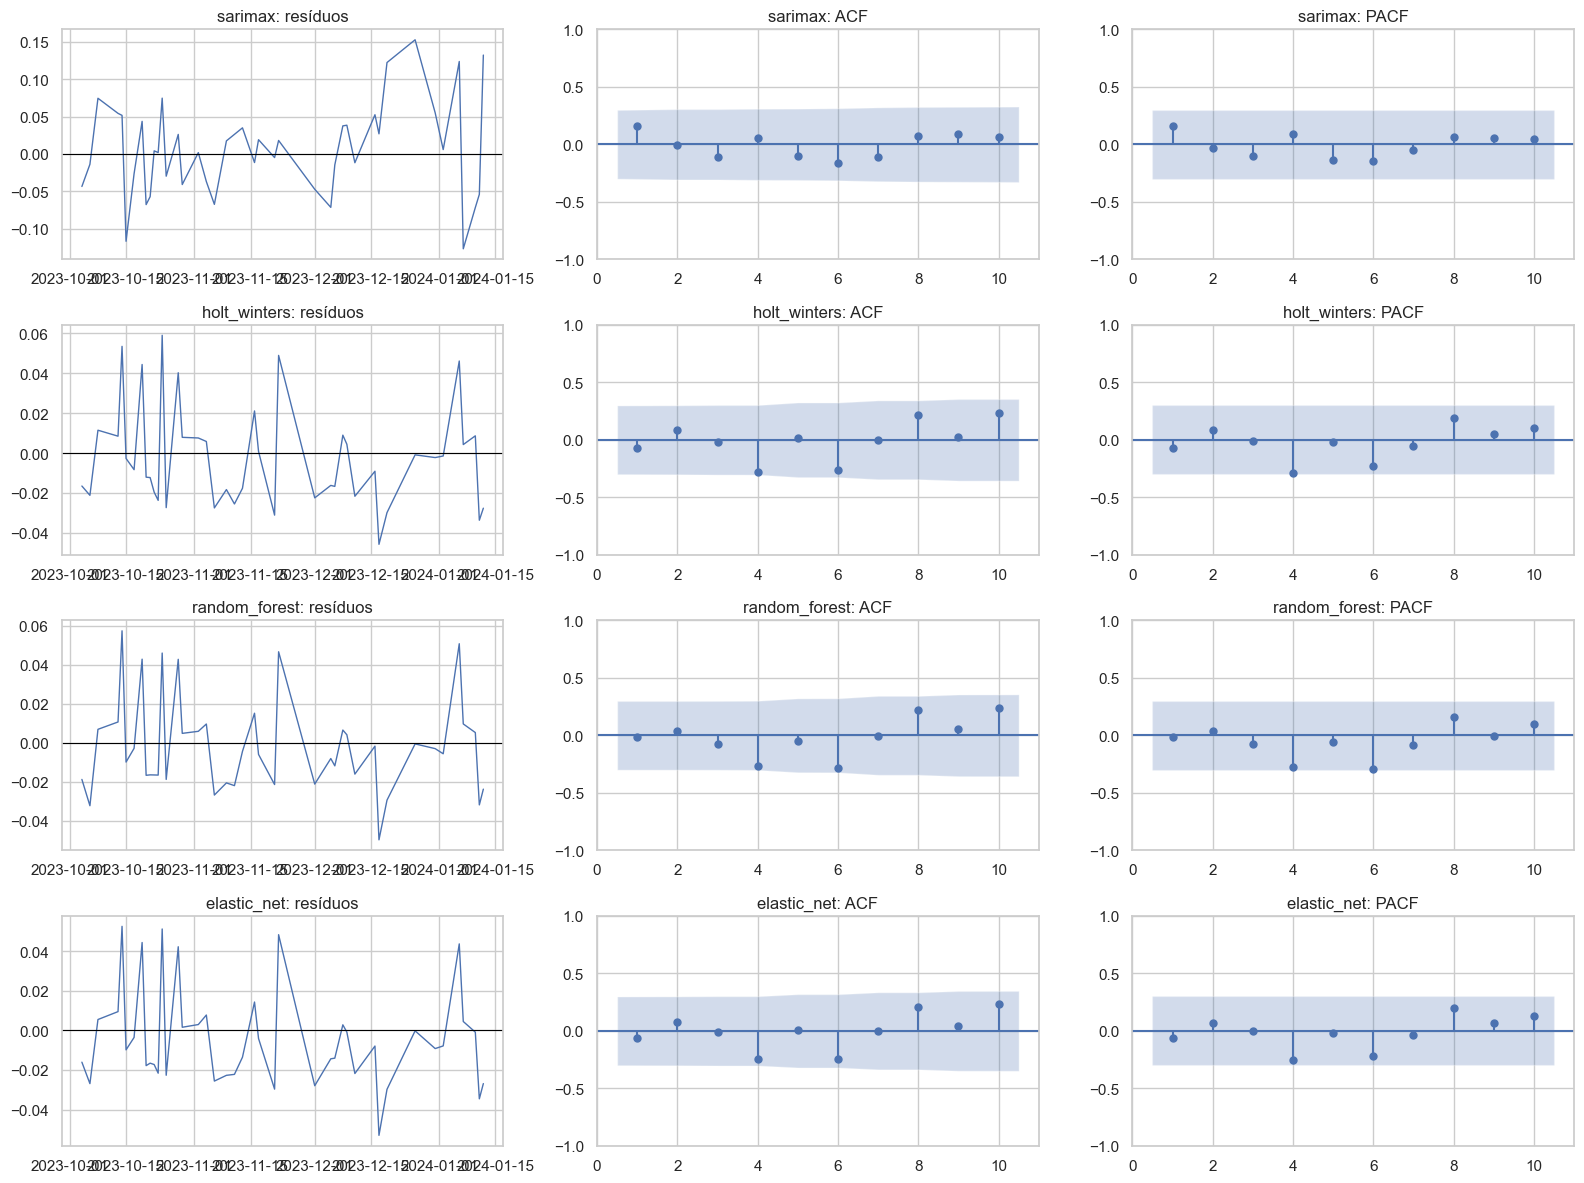

,base_id,model,lag,lb_stat,p_value,n_residuals
0,base_04,sarimax,5,2.393103,0.792501,43
1,base_04,sarimax,10,5.470818,0.857594,43
2,base_04,holt_winters,5,4.436457,0.488430,43
3,base_04,holt_winters,10,13.844925,0.180183,43
4,base_04,random_forest,5,3.990831,0.550737,43
5,base_04,random_forest,10,14.122815,0.167463,43
6,base_04,elastic_net,5,3.408528,0.637271,43
7,base_04,elastic_net,10,12.320904,0.264153,43


In [8]:
ljung_rows = []
fig, axes = plt.subplots(len(model_names), 3, figsize=(16, 12))
for row_idx, model_name in enumerate(model_names):
    pred_df = predictions[model_name].copy()
    pred_df['residual'] = pred_df['y_true'] - pred_df['y_pred']
    pred_df[['origin_date', 'forecast_date', 'y_true', 'y_pred', 'residual']].to_csv(DATA_DIR / f'residuals_{model_name}_{BASE_ID}.csv', index=False)
    residuals = pred_df['residual']
    residual_lags = min(15, max(5, len(residuals) // 4))
    axes[row_idx, 0].plot(pred_df['forecast_date'], residuals, linewidth=1)
    axes[row_idx, 0].axhline(0, color='black', linewidth=0.8)
    axes[row_idx, 0].set_title(f'{model_name}: resíduos')
    plot_acf(residuals, lags=residual_lags, ax=axes[row_idx, 1], zero=False)
    axes[row_idx, 1].set_title(f'{model_name}: ACF')
    plot_pacf(residuals, lags=residual_lags, ax=axes[row_idx, 2], zero=False, method='ywm')
    axes[row_idx, 2].set_title(f'{model_name}: PACF')
    for lag in [5, 10]:
        lb = acorr_ljungbox(residuals, lags=[lag], return_df=True).iloc[0]
        ljung_rows.append({
            'base_id': BASE_ID,
            'model': model_name,
            'lag': lag,
            'lb_stat': float(lb['lb_stat']),
            'p_value': float(lb['lb_pvalue']),
            'n_residuals': len(residuals),
        })
plt.tight_layout()
plt.show()

ljung_table = pd.DataFrame(ljung_rows)
ljung_table.to_csv(DATA_DIR / f'ljung_box_{BASE_ID}.csv', index=False)
display(ljung_table)

In [9]:
full_x = samples[feature_cols]
full_y = samples['target']

final_rf = clone(rf_base).set_params(**rf_params).fit(full_x, full_y)
final_en = clone(en_base).set_params(**en_params).fit(full_x, full_y)
joblib.dump(final_rf, ARTIFACT_DIR / 'random_forest.pkl')
joblib.dump(final_en, ARTIFACT_DIR / 'elastic_net.pkl')

rf_importance = pd.Series(final_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
en_coef = pd.Series(final_en.named_steps['model'].coef_, index=feature_cols).sort_values(key=np.abs, ascending=False)

display(rf_importance.head(10))
display(en_coef.head(10))

required_paths = [
    DATA_DIR / f'cleaned_{BASE_ID}.csv',
    DATA_DIR / f'features_{BASE_ID}.parquet',
    DATA_DIR / f'mae_{BASE_ID}.csv',
    DATA_DIR / f'ljung_box_{BASE_ID}.csv',
]
for model_name in model_names:
    required_paths.extend([
        DATA_DIR / f'predictions_{model_name}_{BASE_ID}.csv',
        DATA_DIR / f'residuals_{model_name}_{BASE_ID}.csv',
    ])
    assert (ARTIFACT_DIR / f'{model_name}.pkl').exists() if model_name in ['random_forest', 'elastic_net'] else True

assert all(p.exists() for p in required_paths)
print(f'VALIDAÇÃO FINAL OK: {len(required_paths)} arquivos de dados e artefatos confirmados.')

relationship_lag_1    0.086725
doy_cos               0.073686
return_std_30         0.071379
jp_lag_1              0.069622
return_mean_30        0.055586
return_mean_7         0.055013
target_lag_7          0.053125
target_mean_30        0.052238
target_std_30         0.051343
tf_lag_1              0.047714
dtype: float64

target_lag_1         -0.0
target_lag_7          0.0
sn_lag_1              0.0
tf_lag_1             -0.0
jp_lag_1             -0.0
happiness_lag_1      -0.0
sadness_lag_1        -0.0
surprise_lag_1       -0.0
relationship_lag_1    0.0
target_mean_7        -0.0
dtype: float64

VALIDAÇÃO FINAL OK: 12 arquivos de dados e artefatos confirmados.
